In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [8]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [9]:
df = df.dropna(subset=["TotalCharges"])

In [10]:
print("Missing values:")
print(df.isnull().sum().sum())

print("Dataset shape:")
print(df.shape)

Missing values:
0
Dataset shape:
(7032, 21)


In [11]:
df["TotalCharges"].dtype

dtype('float64')

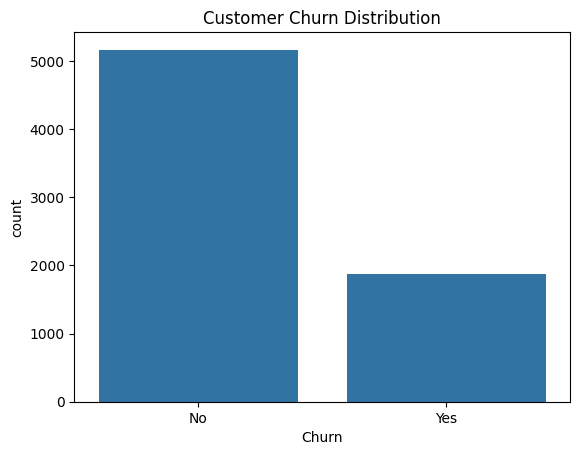

In [12]:
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

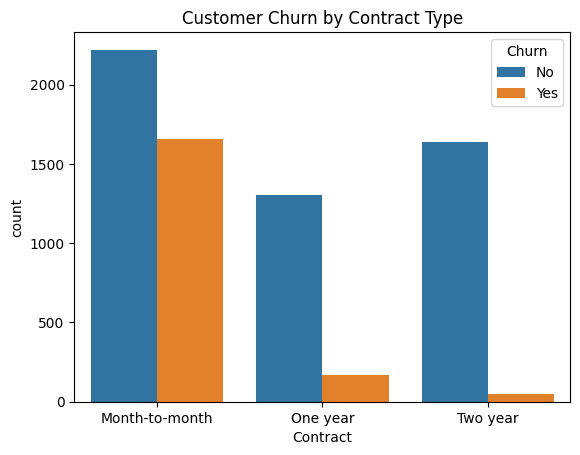

In [13]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Customer Churn by Contract Type")
plt.show()

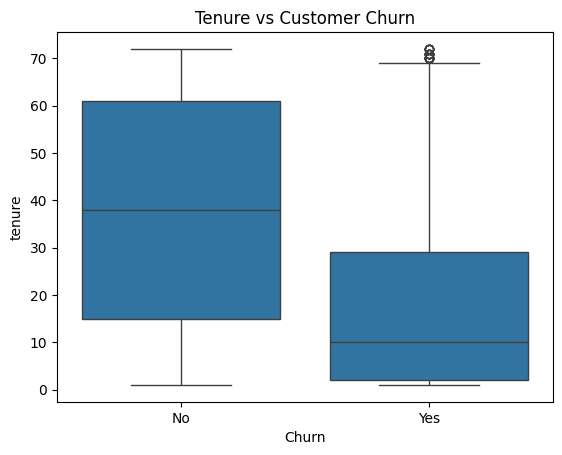

In [14]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Customer Churn")
plt.show()

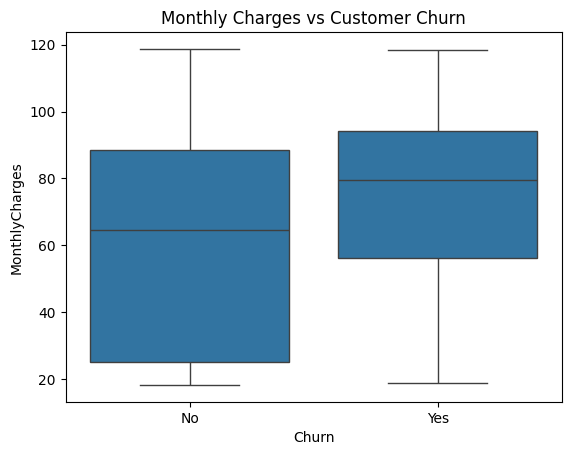

In [15]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Customer Churn")
plt.show()

In [16]:
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"No": 0, "Yes": 1})

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 20)
y shape: (7032,)


In [17]:
X = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X.shape)

Shape after encoding: (7032, 7061)


In [18]:
# Remove customerID before encoding
X = df.drop(["Churn", "customerID"], axis=1)

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X.shape)

Shape after encoding: (7032, 30)


In [19]:
X.columns.tolist()

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'gender_Male',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


## Logistic Regression

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

## Evaluate Logistic Regression

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-Score:", f1_score(y_test, y_pred_lr))

Accuracy: 0.8038379530916845
Precision: 0.6475903614457831
Recall: 0.5748663101604278
F1-Score: 0.6090651558073654


## Train Decision Tree

In [25]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [26]:
print("Decision Tree Performance:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Performance:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-Score:", f1_score(y_test, y_pred_dt))

Accuracy: 0.7782515991471215
Precision: 0.5807291666666666
Recall: 0.5962566844919787
F1-Score: 0.5883905013192612


In [28]:
dt_model.feature_importances_

array([0.00930987, 0.4412833 , 0.02519761, 0.03388634, 0.        ,
       0.        , 0.        , 0.00758628, 0.        , 0.01013401,
       0.33882621, 0.        , 0.02677808, 0.0151383 , 0.        ,
       0.00906725, 0.        , 0.        , 0.        , 0.01215941,
       0.        , 0.        , 0.0154017 , 0.        , 0.00911129,
       0.01931153, 0.        , 0.        , 0.02680882, 0.        ])

## comparison table

In [29]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.803838,0.647590,0.574866,0.609065
1,Decision Tree,0.778252,0.580729,0.596257,0.588391


## Model Performance Comparison

The Logistic Regression model achieved better accuracy, precision, and F1-score than the Decision Tree. However, the Decision Tree achieved slightly higher recall, meaning it identified a slightly larger proportion of customers who actually churned.

## Now find the Top 3 Churn Features

In [30]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,tenure,0.441283
10,InternetService_Fiber optic,0.338826
3,TotalCharges,0.033886
28,PaymentMethod_Electronic check,0.026809
12,OnlineSecurity_No internet service,0.026778
2,MonthlyCharges,0.025198
25,Contract_Two year,0.019312
22,StreamingMovies_No internet service,0.015402
13,OnlineSecurity_Yes,0.015138
19,TechSupport_Yes,0.012159


In [31]:
top_3 = feature_importance.head(3)

top_3

,Feature,Importance
1,tenure,0.441283
10,InternetService_Fiber optic,0.338826
3,TotalCharges,0.033886


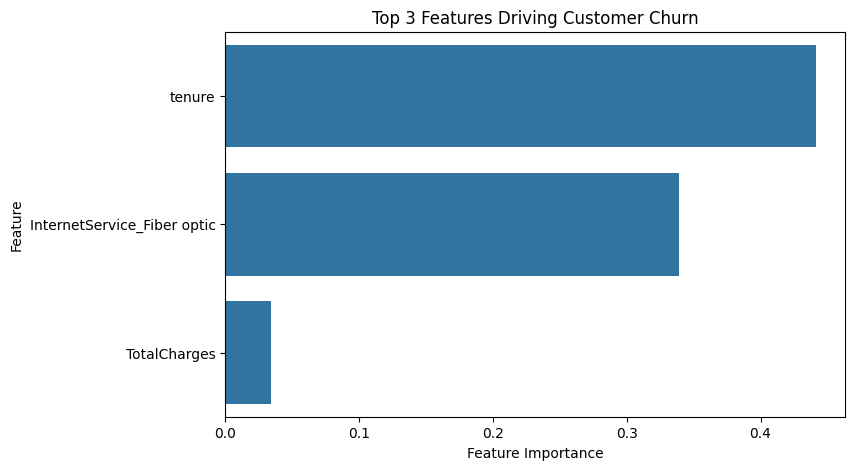

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_3,
    x="Importance",
    y="Feature"
)

plt.title("Top 3 Features Driving Customer Churn")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [33]:
top_3

,Feature,Importance
1,tenure,0.441283
10,InternetService_Fiber optic,0.338826
3,TotalCharges,0.033886


## Business Summary

Our analysis shows that customer tenure is the strongest factor associated with predicting churn, followed by Fiber Optic Internet Service and Total Charges. The models achieved around 80% accuracy with Logistic Regression performing better overall than the Decision Tree, although the Decision Tree had slightly higher recall. Customers at higher risk of leaving should be identified early so the company can provide targeted retention offers and support. The business could focus particularly on newer customers and customers using Fiber Optic Internet Service when designing retention strategies. Using these predictions can help the company prioritize customers who may need additional attention and potentially reduce customer loss.

## Conclusion

In this project, we developed two machine learning models to predict customer churn: Logistic Regression and Decision Tree.

The dataset contained 7,043 customers initially, and 11 rows with missing `TotalCharges` values were removed, leaving 7,032 customers for modeling. The target variable was imbalanced, with approximately 73.5% non-churn customers and 26.5% churn customers.

Logistic Regression achieved 80.38% accuracy and an F1-score of 60.96%, while the Decision Tree achieved 77.83% accuracy and an F1-score of 58.84%. The Decision Tree had slightly higher recall (59.63%) compared with Logistic Regression (57.49%).

The Decision Tree's three most important features were tenure, Fiber Optic Internet Service, and Total Charges. These insights can help a business identify customers who may be at higher risk of churn and develop targeted retention strategies.